BANK CHURNERS:  
Khách hàng nào đã rời bỏ dịch vụ thẻ tín dụng của ngân hàng  
#Biến mục tiêu  
Attrition_Flag:
                Existing Customer = khách hàng còn sử dụng  
                Attrited Customer = khách hàng đã rời bỏ (churn)  
                    
#Nhóm thông tin nhân khẩu học  
CLIENTNUM  (Mã khách hàng ID)  
Customer_Age  (Tuổi khách hàng)  
Gender (Nam/Nữ)  
Dependent_count (số người phụ thuộc)   
Education_Level (Trình độ học vấn)  
Marital_Status (Tình trạng hôn nhân)  
Income_Category (Nhóm thu nhập)  
  
#Nhóm thông tin quan hệ với ngân hàng  
Months_on_book (Số tháng là khách hàng của ngân hàng)  
Total_Relationship_Count (Số sản phẩm khách hàng đang sử dụng, Ví dụ: thẻ tín dụng, tiết kiệm, vay vốn,...)
     
#Nhóm thông tin thẻ tín dụng  
Card_Category (Loại thẻ:Blue, Silver, Gold, Platinum)  
Credit_Limit (Hạn mức tín dụng)  
  
#Nhóm hoạt động giao dịch  
Months_Inactive_12_mon(Số tháng không hoạt động trong 12 tháng gần nhất)  
Contacts_Count_12_mon(Số lần liên hệ với ngân hàng trong 12 tháng)  
Total_Trans_Amt (Tổng giá trị giao dịch trong năm)  
Total_Trans_Ct (Tổng số lượng giao dịch trong năm )   
  
#Nhóm chỉ số thay đổi theo thời gian  
Total_Revolving_Bal (Dư nợ quay vòng trên thẻ)  
Avg_Open_To_Buy (Hạn mức còn khả dụng)  
Total_Amt_Chng_Q4_Q1 (Tỷ lệ thay đổi giá trị giao dịch từ Q1 đến Q4, Ví dụ: = 1.2 → tăng 20%, = 0.8 → giảm 20%)  
Total_Ct_Chng_Q4_Q1 (Tỷ lệ thay đổi số lượng giao dịch từ Q1 đến Q4)  
Avg_Utilization_Ratio (Hệ số sử dụng thẻ trung bình hoặc Tỷ lệ tiêu dùng trên hạn mức tín dụng)  

#### Step1: Import 

In [2]:
#Standard import
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt   #chỉ cài phần vẽ plot của gói matplotlib
import seaborn as sns            #visualize
from collections import Counter

In [3]:
#Sklearn: chạy ML (dự báo, phân loại, phân cụm) -> cài dưới terminal: pip install scikit-learn
from sklearn.model_selection import train_test_split, StratifiedGroupKFold, cross_val_score
#train_test_split    # chia data thành tập train/test
#StratifiedKFold     # chia K fold, giữ tỷ lệ class cân bằng
#cross_val_score     # đánh giá model bằng cross validation

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
#StandardScaler   # chuẩn hóa về mean=0, std=1
#MinMaxScaler     # scale về khoảng [0, 1]
#OneHotEncoder    # mã hóa categorical → dạng 0/1 (vd: ["IT","HR"] → [1,0], [0,1])
#LabelEncoder     # mã hóa label → số (vd: "cat"→0, "dog"→1)

from sklearn.compose import ColumnTransformer 
# áp dụng các transform khác nhau cho từng cột

from sklearn.pipeline import Pipeline
#SimpleImputer  # điền giá trị vào chỗ bị thiếu (mean, median, most_frequent...)




#### Step 2: Import data


In [4]:
df = pd.read_csv("d:\\Python\\BankChurnersfirst.csv")
df

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


#### Step 3: Initial inspection

In [5]:
df.isna().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

There are no missing values in the dataset; therefore, no imputation was required.

In [6]:
df1 = df.drop(columns=['CLIENTNUM', 
                      'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                      'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'])
df1

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [7]:
df1.describe()     #như summarise R

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894
std,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691
min,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000
25%,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000
50%,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000
75%,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000
max,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000


In [8]:
print(df1.dtypes)


Attrition_Flag                  str
Customer_Age                  int64
Gender                          str
Dependent_count               int64
Education_Level                 str
Marital_Status                  str
Income_Category                 str
Card_Category                   str
Months_on_book                int64
Total_Relationship_Count      int64
Months_Inactive_12_mon        int64
Contacts_Count_12_mon         int64
Credit_Limit                float64
Total_Revolving_Bal           int64
Avg_Open_To_Buy             float64
Total_Amt_Chng_Q4_Q1        float64
Total_Trans_Amt               int64
Total_Trans_Ct                int64
Total_Ct_Chng_Q4_Q1         float64
Avg_Utilization_Ratio       float64
dtype: object


In [9]:
# Xem số lượng loại của từng cột categorical
for col in df1.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} loại → {df[col].unique()}")

Attrition_Flag: 2 loại → <StringArray>
['Existing Customer', 'Attrited Customer']
Length: 2, dtype: str
Gender: 2 loại → <StringArray>
['M', 'F']
Length: 2, dtype: str
Education_Level: 7 loại → <StringArray>
[  'High School',      'Graduate',    'Uneducated',       'Unknown',
       'College', 'Post-Graduate',     'Doctorate']
Length: 7, dtype: str
Marital_Status: 4 loại → <StringArray>
['Married', 'Single', 'Unknown', 'Divorced']
Length: 4, dtype: str
Income_Category: 6 loại → <StringArray>
[   '$60K - $80K', 'Less than $40K',   '$80K - $120K',    '$40K - $60K',
        '$120K +',        'Unknown']
Length: 6, dtype: str
Card_Category: 4 loại → <StringArray>
['Blue', 'Gold', 'Silver', 'Platinum']
Length: 4, dtype: str


C:\Users\Admin\AppData\Local\Temp\ipykernel_6288\2576563441.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df1.select_dtypes(include='object').columns:


In [10]:
#Encoding cột Attrition bằng 0-1 (có thứ bậc)
df1['Attrition_Flag'] = df1['Attrition_Flag'].replace({
    'Existing Customer': 0,
    'Attrited Customer': 1})

df1

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,50,M,2,Graduate,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,1,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,1,44,F,1,High School,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,1,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [11]:
df1['Education_Level'] = df1['Education_Level'].replace({
    'Uneducated': 0,
    'High School': 1,
    'College': 2,
    'Graduate': 3,
    'Post-Graduate': 4,
    'Doctorate': 5,
    'Unknown': -1 })

df1

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,1,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,3,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,3,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,1,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,0,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,50,M,2,3,Single,$40K - $60K,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,1,41,M,2,-1,Divorced,$40K - $60K,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,1,44,F,1,1,Married,Less than $40K,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,1,30,M,2,3,Unknown,$40K - $60K,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [12]:
# Xem kĩ từng biểu hiện của biến
print(df1['Income_Category'].value_counts())
print()
print(f"Tổng số loại: {df['Income_Category'].nunique()}")
print(f"Số hàng Unknown: {(df['Income_Category'] == 'Unknown').sum()}")

Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64

Tổng số loại: 6
Số hàng Unknown: 1112


In [13]:
df1['Income_Category'] = df1['Income_Category'].replace({
    'Less than $40K': 0,
    '$40K - $60K': 1,
    '$80K - $120K': 2,
    '$60K - $80K': 3,
    '$120K +': 4,
    'Unknown': -1 })

df1

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,0,45,M,3,1,Married,3,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,0,49,F,5,3,Single,0,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,0,51,M,3,3,Married,2,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,0,40,F,4,1,Unknown,0,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,0,40,M,3,0,Married,3,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,50,M,2,3,Single,1,Blue,40,3,2,3,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462
10123,1,41,M,2,-1,Divorced,1,Blue,25,4,2,3,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511
10124,1,44,F,1,1,Married,0,Blue,36,5,3,4,5409.0,0,5409.0,0.819,10291,60,0.818,0.000
10125,1,30,M,2,3,Unknown,1,Blue,36,4,3,3,5281.0,0,5281.0,0.535,8395,62,0.722,0.000


In [14]:
# Thực hiện One-Hot Encoding cho các cột không có thứ tự (k có thang đo thứ bậc)
# Tham số drop_first=True dùng để xóa bớt 1 cột thừa nhằm tránh hiện tượng đa cộng tuyến (ví dụ chỉ cần giữ lại cột Gender_M là đủ hiểu, nếu Gender_M = 0 thì tự khắc người đó là Nữ)
df2 = pd.get_dummies(df1, columns=['Gender', 'Marital_Status', 'Card_Category'], drop_first=True, dtype=int)
df2

,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,45,3,1,3,39,5,1,3,12691.0,...,42,1.625,0.061,1,1,0,0,0,0,0
1,0,49,5,3,0,44,6,1,2,8256.0,...,33,3.714,0.105,0,0,1,0,0,0,0
2,0,51,3,3,2,36,4,1,0,3418.0,...,20,2.333,0.000,1,1,0,0,0,0,0
3,0,40,4,1,0,34,3,4,1,3313.0,...,20,2.333,0.760,0,0,0,1,0,0,0
4,0,40,3,0,3,21,5,1,0,4716.0,...,28,2.500,0.000,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,50,2,3,1,40,3,2,3,4003.0,...,117,0.857,0.462,1,0,1,0,0,0,0
10123,1,41,2,-1,1,25,4,2,3,4277.0,...,69,0.683,0.511,1,0,0,0,0,0,0
10124,1,44,1,1,0,36,5,3,4,5409.0,...,60,0.818,0.000,0,1,0,0,0,0,0
10125,1,30,2,3,1,36,4,3,3,5281.0,...,62,0.722,0.000,1,0,0,1,0,0,0


In [15]:
#Scale các cột số (ko gồm các cột vừa mã hóa): dùng để train model
from sklearn.preprocessing import StandardScaler
num_cols = ['Customer_Age', 'Dependent_count', 'Months_on_book',
            'Total_Relationship_Count', 'Months_Inactive_12_mon',
            'Contacts_Count_12_mon', 'Credit_Limit',
            'Total_Revolving_Bal', 'Avg_Open_To_Buy',
            'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
            'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1',
            'Avg_Utilization_Ratio']
df3 = df2.copy()
scaler = StandardScaler()
df3[num_cols] = scaler.fit_transform(df2[num_cols])
df3


,Attrition_Flag,Customer_Age,Dependent_count,Education_Level,Income_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,...,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Gender_M,Marital_Status_Married,Marital_Status_Single,Marital_Status_Unknown,Card_Category_Gold,Card_Category_Platinum,Card_Category_Silver
0,0,-0.165406,0.503368,1,3,0.384621,0.763943,-1.327136,0.492404,0.446622,...,-0.973895,3.834003,-0.775882,1,1,0,0,0,0,0
1,0,0.333570,2.043199,3,0,1.010715,1.407306,-1.327136,-0.411616,-0.041367,...,-1.357340,12.608573,-0.616276,0,0,1,0,0,0,0
2,0,0.583058,0.503368,3,2,0.008965,0.120579,-1.327136,-2.219655,-0.573698,...,-1.911206,6.807864,-0.997155,1,1,0,0,0,0,0
3,0,-0.789126,1.273283,1,0,-0.241473,-0.522785,1.641478,-1.315636,-0.585251,...,-1.911206,6.807864,1.759686,0,0,0,1,0,0,0
4,0,-0.789126,0.503368,0,3,-1.869317,0.763943,-1.327136,-2.219655,-0.430877,...,-1.570365,7.509325,-0.997155,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0,0.458314,-0.266547,3,1,0.509840,-0.522785,-0.337598,0.492404,-0.509330,...,2.221481,0.608119,0.678714,1,0,1,0,0,0,0
10123,1,-0.664382,-0.266547,-1,1,-1.368442,0.120579,-0.337598,0.492404,-0.479181,...,0.176440,-0.122745,0.856458,1,0,0,0,0,0,0
10124,1,-0.290150,-1.036462,1,0,0.008965,0.763943,0.651940,1.396424,-0.354626,...,-0.207005,0.444305,-0.997155,0,1,0,0,0,0,0
10125,1,-2.036565,-0.266547,3,1,0.008965,0.120579,0.651940,0.492404,-0.368710,...,-0.121795,0.041070,-0.997155,1,0,0,1,0,0,0


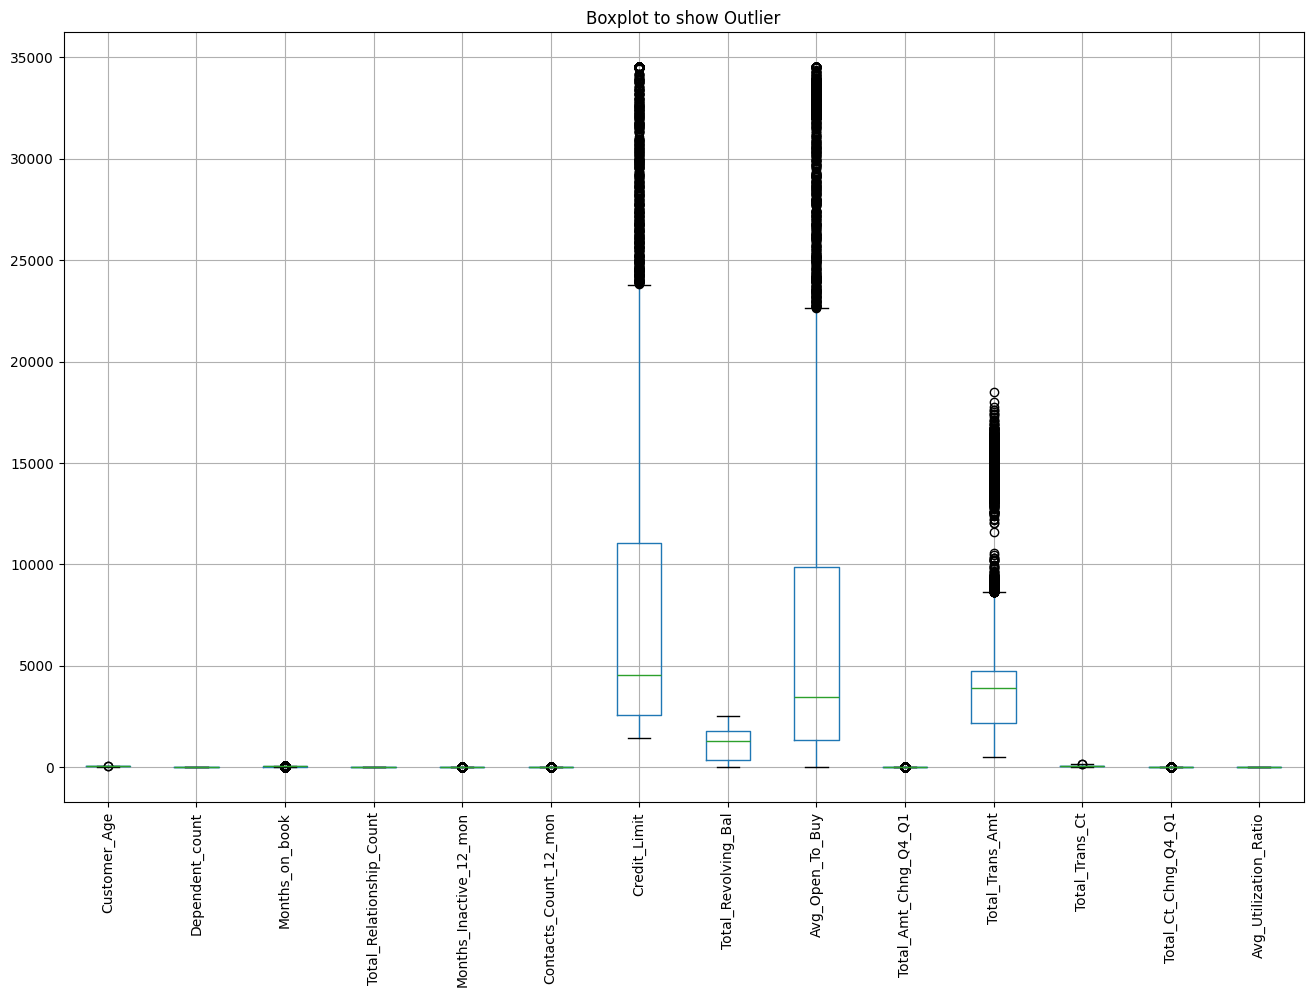

In [16]:
# Boxplot tất cả cột số để xem outlier
plt.figure(figsize=(16, 10))
df[num_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Boxplot to show Outlier')
plt.show()

Several numerical variables contain outliers, particularly in transaction and credit-related features. These extreme values may represent customers with unusually high financial activity rather than data entry errors. Therefore, the outliers were retained to preserve valuable business information and maintain the integrity of customer behavior patterns.

#### Step 4: EDA (Exploratory Data Analysis)

In [17]:
df_copy = pd.read_csv("d:\\Python\\BankChurnersfirst.csv")
df_copy1 = df_copy.drop(columns=['CLIENTNUM', 
                      'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                      'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'])
df_copy1.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


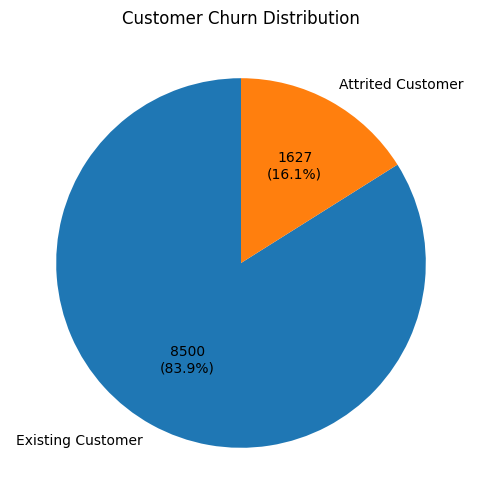

In [18]:
counts = df_copy1['Attrition_Flag'].value_counts()

def autopct_format(values):
    def my_format(pct):
        total = sum(values)
        count = int(round(pct * total / 100))
        return f'{count}\n({pct:.1f}%)'
    return my_format

plt.figure(figsize=(6,6))

plt.pie(
    counts,
    labels=counts.index,
    autopct=autopct_format(counts),
    startangle=90
)

plt.title('Customer Churn Distribution')
plt.show()

The dataset exhibits class imbalance, the number of Existing Customers (over 8,000) heavily outweighs the Attrited Customers (around 1,600). The ratio is roughly 84% to 16%.

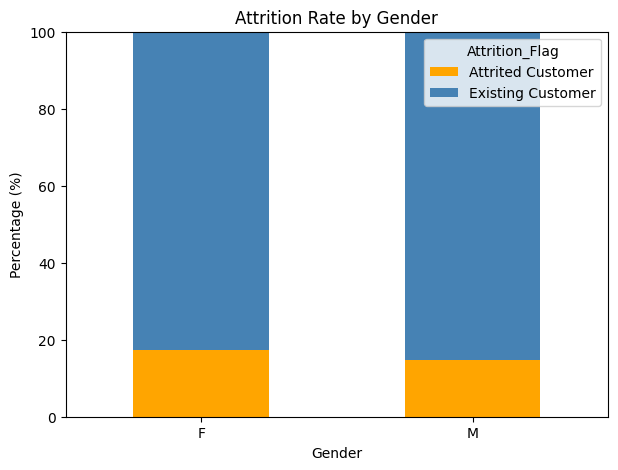

In [19]:
gender_pct = pd.crosstab(
    df_copy1['Gender'],
    df_copy1['Attrition_Flag'],
    normalize='index'
) * 100

gender_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5),  color=['orange', 'steelblue']
)

plt.title('Attrition Rate by Gender')
plt.ylabel('Percentage (%)')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.ylim(0,100)
plt.show()

While the dataset contains slightly more female customers overall, the chart shows that the absolute number of churned customers (Attrited Customer) is noticeably higher for Females (F) than for Males (M). Proportional Churn Rate of Males (M) is roughly 700 churned out of 4,700 total (approximately 14.9% churn rate). While the rate for Females (F) is roughly 950 churned out of 5,300 total (approximately 17.9% churn rate).

(array([0, 1, 2, 3, 4, 5]),
 [Text(0, 0, '$120K +'),
  Text(1, 0, '$40K - $60K'),
  Text(2, 0, '$60K - $80K'),
  Text(3, 0, '$80K - $120K'),
  Text(4, 0, 'Less than $40K'),
  Text(5, 0, 'Unknown')])

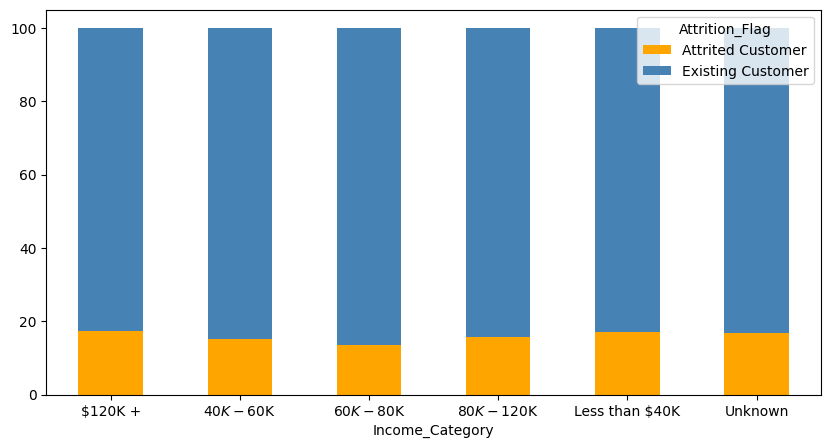

In [20]:
income_pct = pd.crosstab(
    df_copy1['Income_Category'],
    df_copy1['Attrition_Flag'],
    normalize='index') * 100

income_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5),  color=['orange', 'steelblue']
)
plt.xticks(rotation=0)

The customer churn rate (Attrited Customer) across all income groups was almost uniform, fluctuating steadily between 14% and 17.5%.  
The highest-income group ($120,000+) and the lowest-income group (less than $40,000) had slightly higher churn rates than the others (around 17.5%). However, this difference was negligible.  
-> Income Category was not a decisive factor or a strong influence on customer churn behavior.

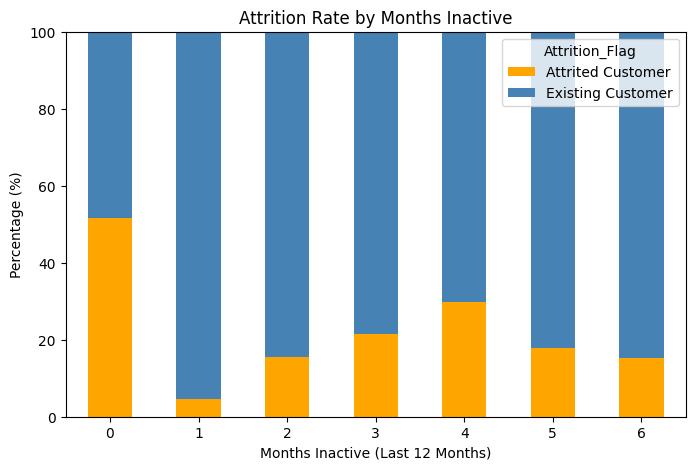

In [21]:
# Tính tỷ lệ %
inactive_pct = pd.crosstab(
    df_copy1['Months_Inactive_12_mon'],
    df_copy1['Attrition_Flag'],
    normalize='index') * 100

# Vẽ stacked bar 100%
inactive_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5),  color=['orange', 'steelblue'])

plt.title('Attrition Rate by Months Inactive')
plt.xlabel('Months Inactive (Last 12 Months)')
plt.xticks(rotation=0)
plt.ylabel('Percentage (%)')
plt.legend(title='Attrition_Flag')
plt.ylim(0, 100)

plt.show()

Customers with longer inactive periods are more likely to churn. Inactivity of three months or more appears to be a strong warning signal of customer attrition.

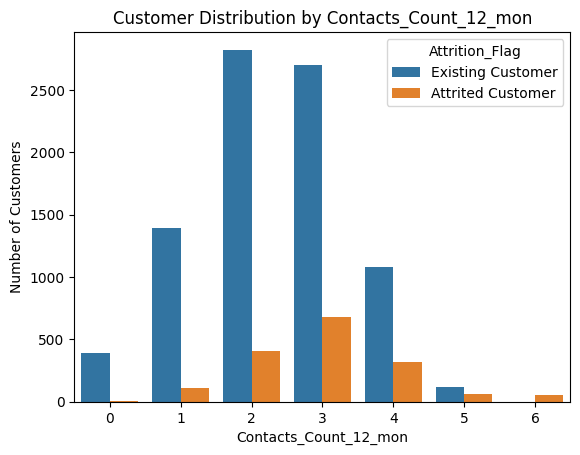

In [22]:
sns.countplot(x='Contacts_Count_12_mon', hue='Attrition_Flag', data=df_copy1)
plt.xticks(rotation=0)
color=['orange', 'steelblue']
plt.title('Customer Distribution by Contacts_Count_12_mon')
plt.ylabel('Number of Customers')
plt.show()

Customers who contact the bank more frequently tend to exhibit higher churn risk, suggesting that repeated customer service interactions may reflect unresolved issues or dissatisfaction.

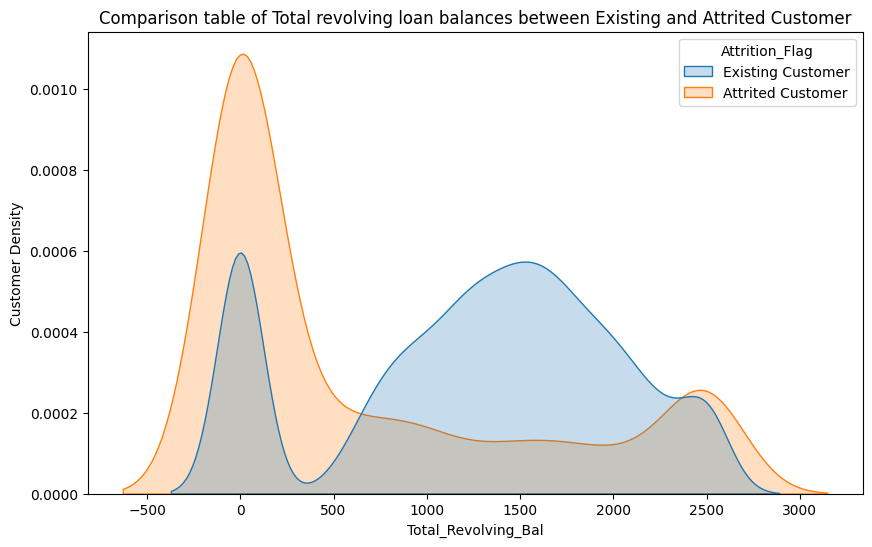

In [23]:
plt.figure(figsize=(10, 6))
# Vẽ biểu đồ mật độ nợ xoay vòng
sns.kdeplot(data=df_copy1, x='Total_Revolving_Bal', hue='Attrition_Flag', fill=True, common_norm=False)
plt.title('Comparison table of Total revolving loan balances between Existing and Attrited Customer')
plt.xlabel('Total_Revolving_Bal')
plt.ylabel('Customer Density')
plt.show()

 Customers with low revolving balances are more likely to churn (looking at the total_revolving_bal from 0 to 500), suggesting that reduced credit card usage may be an early warning sign of customer attrition.

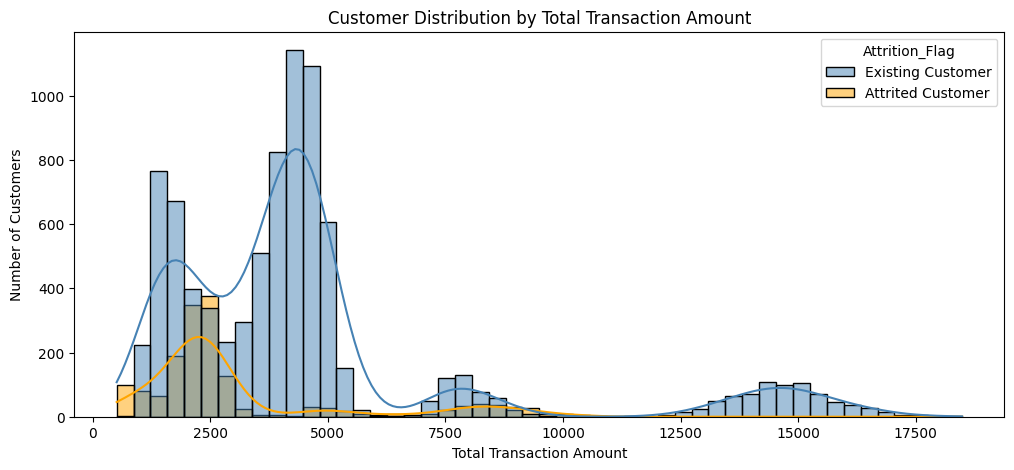

In [24]:
plt.figure(figsize=(12, 5))
sns.histplot(data=df_copy1, x='Total_Trans_Amt', hue='Attrition_Flag',
             kde=True, bins=50,
             palette={'Attrited Customer': 'orange', 'Existing Customer': 'steelblue'})
plt.title('Customer Distribution by Total Transaction Amount')
plt.xlabel('Total Transaction Amount')
plt.ylabel('Number of Customers')
plt.show()

Customers with lower transaction amounts are more likely to churn, suggesting reduced card usage is associated with customer attrition. (Attrited customers are mainly concentrated in the low trading range, around 1,000–3,000). While highly engaged customers with large transaction volumes show strong retention and are less likely to churn (in the 4,000–5,000 range)   
Total_Trans_Amt may be an important predictor in churn prediction models. (compared with Total_Revolving_Bal)



C:\Users\Admin\AppData\Local\Temp\ipykernel_6288\1059855535.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Attrition_Flag
Attrited Customer    3095.025814
Existing Customer    4654.655882
Name: Total_Trans_Amt, dtype: float64

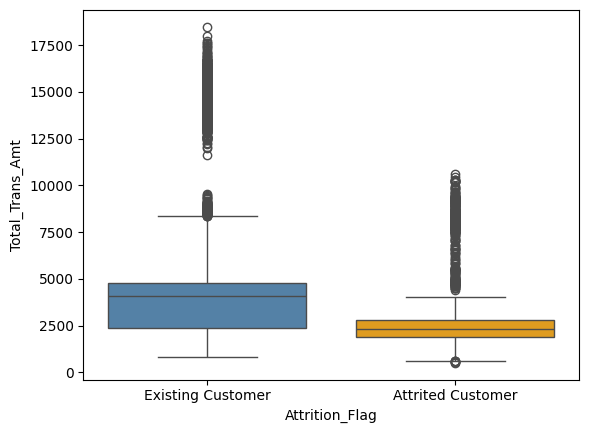

In [25]:
sns.boxplot(
    data=df_copy1,
    x='Attrition_Flag',
    y='Total_Trans_Amt', palette=['steelblue', 'orange']
)

df_copy1.groupby('Attrition_Flag')['Total_Trans_Amt'].mean()

Attrited customers recorded an average transaction significantly lower than Existing customers.

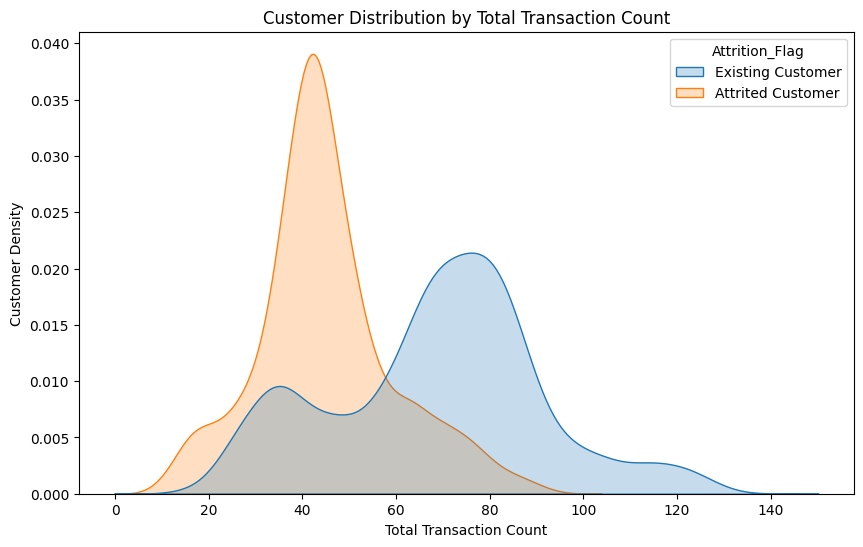

In [26]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df_copy1,
    x='Total_Trans_Ct',
    hue='Attrition_Flag',
    fill=True,
    common_norm=False
)

plt.title('Customer Distribution by Total Transaction Count')
plt.xlabel('Total Transaction Count')
plt.ylabel('Customer Density')
plt.show()

Attrited customers perform substantially fewer transactions than retained customers. Most churned customers are concentrated around 40–50 transactions, whereas retained customers typically make 70–85 transactions. This suggests that transaction frequency is one of the strongest behavioral indicators of customer churn.

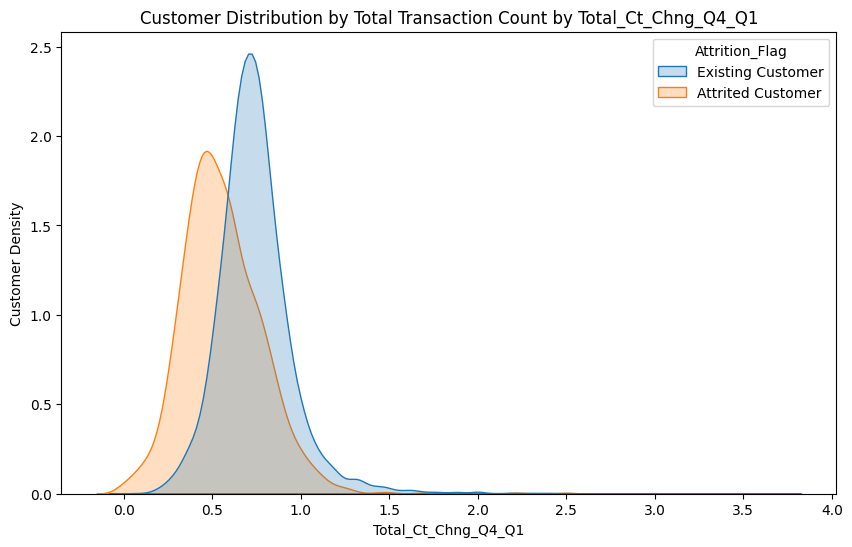

In [27]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_copy1, x='Total_Ct_Chng_Q4_Q1', hue='Attrition_Flag', fill=True, common_norm=False)
plt.title('Customer Distribution by Total Transaction Count by Total_Ct_Chng_Q4_Q1')
plt.xlabel('Total_Ct_Chng_Q4_Q1')
plt.ylabel('Customer Density')
plt.show()

Customers who churn exhibit a significantly lower transaction count change ratio from Q1 to Q4. This suggests that their transaction frequency gradually decreases over time, making behavioral decline a strong indicator of future attrition.

int64


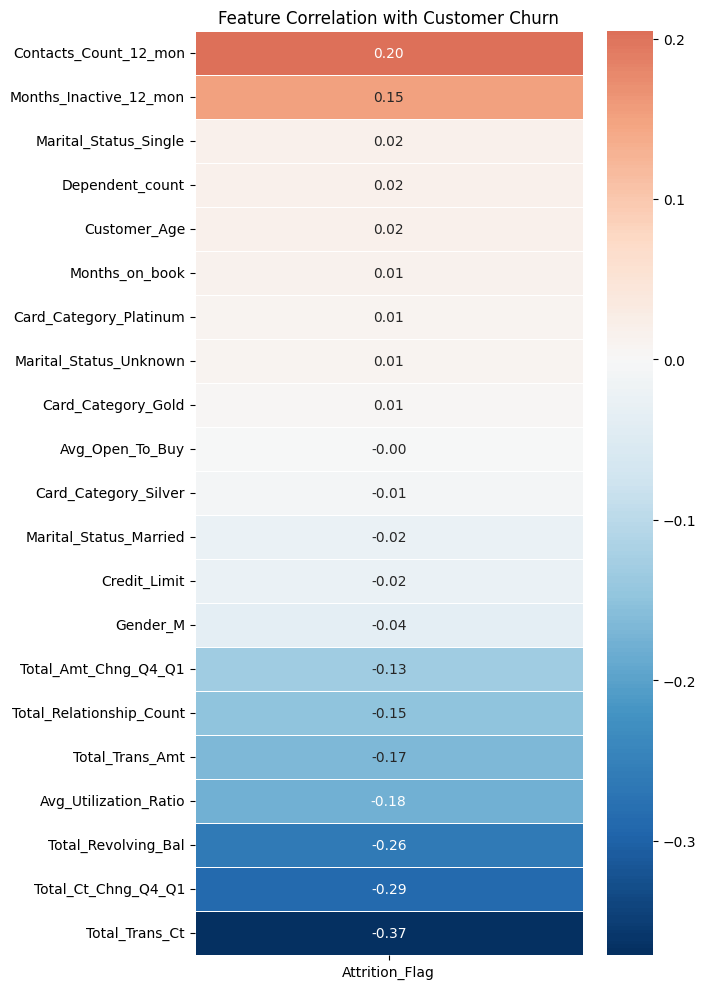

In [28]:
# vẽ headmap toàn bộ features với biến target, dùng data đã encode nhưng chưa scale
df2['Attrition_Flag'] = df2['Attrition_Flag'].astype(int)
print(df2['Attrition_Flag'].dtype)

# Tính tương quan với target
corr_target = df2.corr(numeric_only=True)[['Attrition_Flag']]

# Loại bỏ target tự tương quan với chính nó
corr_target = corr_target.drop('Attrition_Flag')

# Sắp xếp theo độ tương quan
corr_target = corr_target.sort_values(
    by='Attrition_Flag',
    ascending=False
)

# Vẽ heatmap
plt.figure(figsize=(7,10))

sns.heatmap(
    corr_target,
    annot=True,
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    fmt='.2f'
)

plt.title(
    'Feature Correlation with Customer Churn',
    fontsize=12,
    
)

plt.tight_layout()
plt.show()

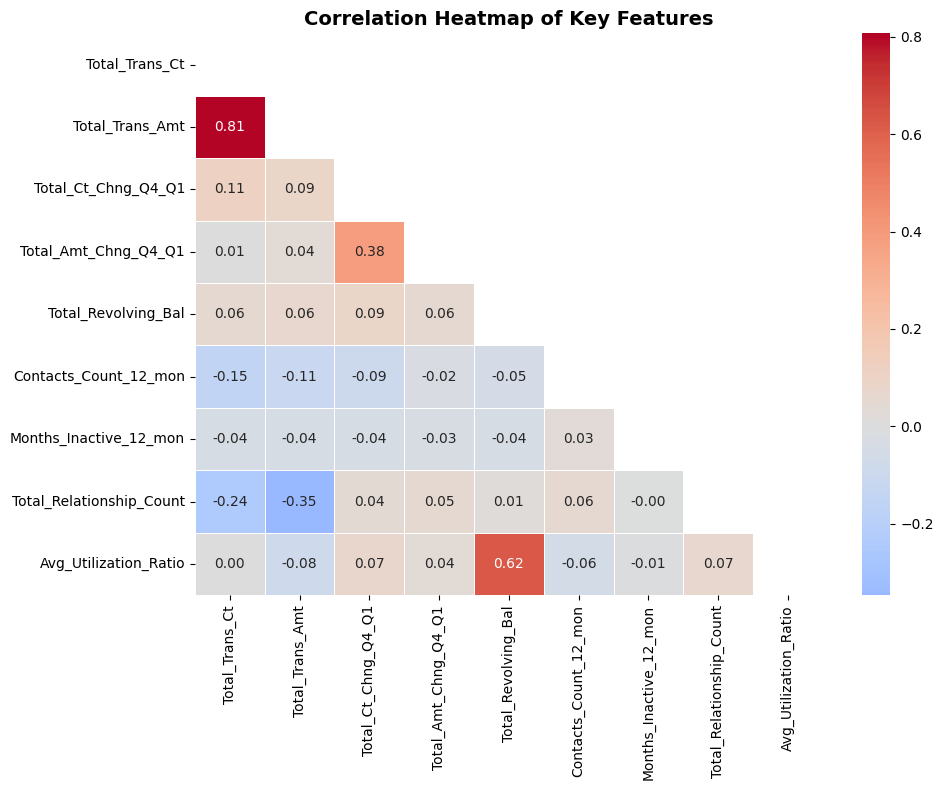

In [29]:
# vẽ heatmap cho các core features và xem multicollinearity
selected_features = [
    
    'Total_Trans_Ct',
    'Total_Trans_Amt',
    'Total_Ct_Chng_Q4_Q1',
    'Total_Amt_Chng_Q4_Q1',
    'Total_Revolving_Bal',
    'Contacts_Count_12_mon',
    'Months_Inactive_12_mon',
    'Total_Relationship_Count',
    'Avg_Utilization_Ratio'
]
corr_matrix = df2[selected_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)

plt.title(
    'Correlation Heatmap of Key Features',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Customers with higher transaction counts (Total_Trans_Ct) are significantly less likely to churn, suggesting that customer engagement is a key retention factor.  
Customers whose transaction activity increased from Q1 to Q4 (Total_Ct_Chng_Q4_Q1) tend to remain active customers.  
Frequent contacts with the bank (Contacts_Count_12_mon) are associated with a higher churn rate, which may indicate unresolved customer issues.  
The heatmap shows strong correlations between several variables, notably "Total_Trans_Ct and Total_Trans_Amt", "Total_Revolving_Bal and Avg_Utilization_Ratio" indicating potential multicollinearity. This should be considered when building interpretable models such as Logistic Regression.

##### #Key Findings from EDA
The dataset contains no missing values, indicating good data quality.  
Several numerical variables contain outliers; however, these observations may represent customers with unusual but valid financial behavior.  
Transaction-related features, particularly Total_Trans_Ct and Total_Trans_Amt, show strong relationships with customer churn.  
Customers with higher inactivity levels and more frequent contacts with the bank are more likely to leave.  
The heatmap reveals some highly correlated variables, suggesting potential multicollinearity that should be considered during model development  

#### Step 5: Train model

##### Logistic regression

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1701
           1       0.78      0.52      0.63       325

    accuracy                           0.90      2026
   macro avg       0.85      0.75      0.78      2026
weighted avg       0.89      0.90      0.89      2026

ROC-AUC: 0.9148


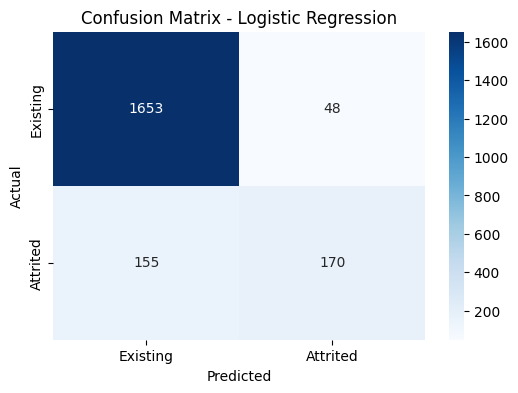

In [30]:
# df3 chưa loại biến nào sau khi thấy đa cộng tuyến
from sklearn.linear_model import LogisticRegression
# Tách X, y từ df3 đã scale

df3['Attrition_Flag'] = df3['Attrition_Flag'].astype(int) 
#Kiểu là object nhưng giá trị là [0 1] → bị lưu sai kiểu dữ liệu

X = df3.drop(columns=['Attrition_Flag'])
y = df3['Attrition_Flag']

# Chia train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) 
# stratify=y: Scikit-learn giữ nguyên tỉ lệ class (exist và attrited) ban đầu trong train và test.

# Train Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Dự đoán
y_pred_lr = lr.predict(X_test)

# Đánh giá
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#precision: Trong số dự đoán churn, đúng bao nhiêu %Class 1: 78%
#recall: Trong số churn thật, bắt được bao nhiêu %Class 1: 52% -> chỉ bắt đc 52% ng churn thật
#f1-score: Trung bình của precision và recallClass 1: 0.63
#support: Số lượng thật trong test setChurn: 325
#accuracy: Tổng đúng / tổng tất cả90%
#ROC-AUC: Khả năng phân biệt churn vs không churn: 0.91 


The dataset was split into training and testing sets using stratified sampling to preserve the original class distribution of churned and existing customers.  
The Logistic Regression model achieved an accuracy of 90% and a ROC-AUC score of 0.915, indicating strong overall predictive performance.  
However, the recall for churned customers was 52% (Recall (class 1) = 0.52), suggesting that a considerable number of at-risk customers were not identified.  
-> This highlights the challenge of class imbalance and suggests that further model optimization may improve churn detection.  

In [31]:
# Coefficient Analysis
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values('Coefficient')
coef_df

,Feature,Coefficient
13,Total_Trans_Ct,-2.704258
16,Gender_M,-0.848897
5,Total_Relationship_Count,-0.748005
9,Total_Revolving_Bal,-0.717453
14,Total_Ct_Chng_Q4_Q1,-0.665008
17,Marital_Status_Married,-0.316715
15,Avg_Utilization_Ratio,-0.095379
11,Total_Amt_Chng_Q4_Q1,-0.084812
4,Months_on_book,-0.079196
8,Credit_Limit,-0.078276


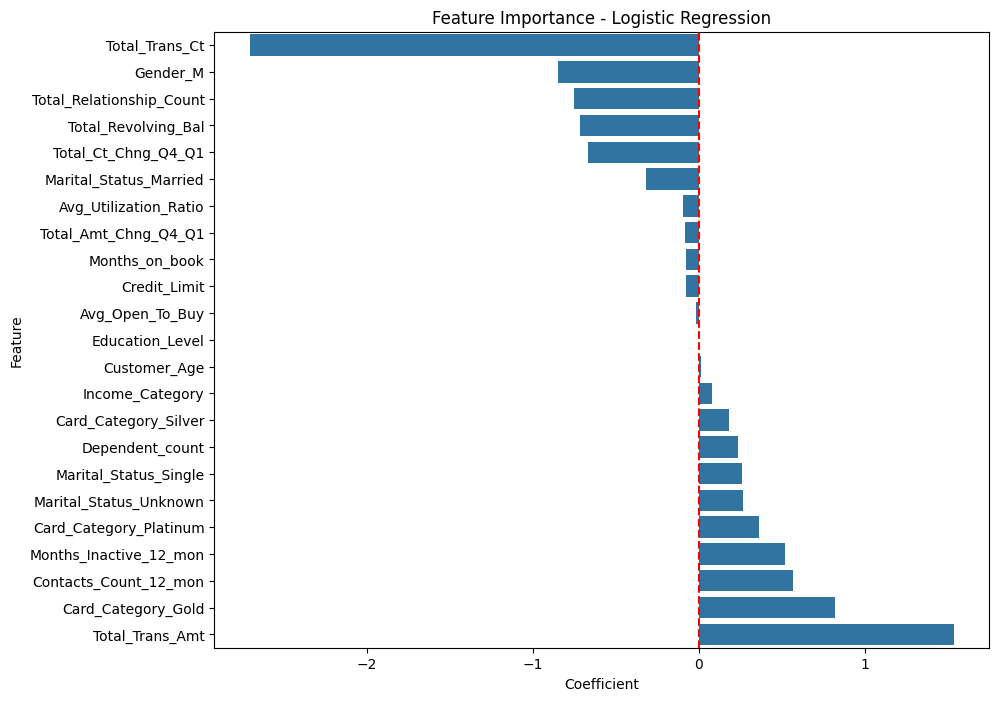

In [32]:
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title('Feature Importance - Logistic Regression')
plt.axvline(x=0, color='red', linestyle='--')
plt.show()

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1701
           1       0.77      0.49      0.60       325

    accuracy                           0.89      2026
   macro avg       0.84      0.73      0.77      2026
weighted avg       0.89      0.89      0.88      2026

ROC-AUC: 0.8838


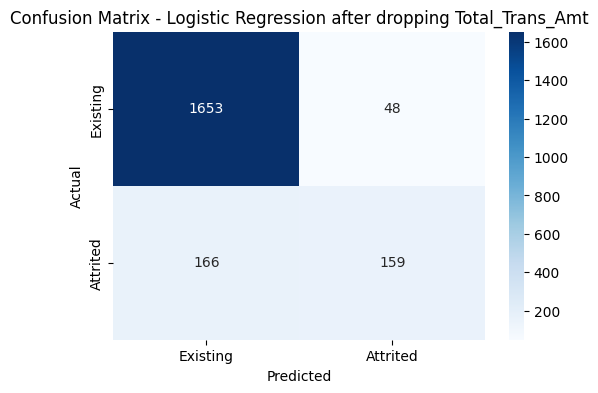

In [33]:
## df3 loại biến 'Total_Trans_Amt' sau khi thấy đa cộng tuyến
df3_drop = df3.drop(columns=['Total_Trans_Amt'])
df3_drop['Attrition_Flag'] = df3_drop['Attrition_Flag'].astype(int) 
#Kiểu là object nhưng giá trị là [0 1] → bị lưu sai kiểu dữ liệu

X = df3_drop.drop(columns=['Attrition_Flag'])
y = df3_drop['Attrition_Flag']

# Chia train/test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) 
# stratify=y: Scikit-learn giữ nguyên tỉ lệ class (exist và attrited) ban đầu trong train và test.

# Train Logistic Regression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr1 = LogisticRegression(max_iter=1000, random_state=42)
lr1.fit(X_train, y_train)

# Dự đoán
y_pred_lr1 = lr1.predict(X_test)

# Đánh giá
print("===== Logistic Regression =====")
print(classification_report(y_test, y_pred_lr1))
print(f"ROC-AUC: {roc_auc_score(y_test, lr1.predict_proba(X_test)[:,1]):.4f}")

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr1),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Existing', 'Attrited'],
            yticklabels=['Existing', 'Attrited'])
plt.title('Confusion Matrix - Logistic Regression after dropping Total_Trans_Amt')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

A correlation analysis revealed a strong positive relationship (0.81) between 'Total_Trans_Ct' and 'Total_Trans_Amt', indicating potential multicollinearity. To evaluate its impact, 'Total_Trans_Amt' was removed and the Logistic Regression model was retrained. The resulting model showed a decrease in ROC-AUC (from 0.9148 to 0.8838) and lower recall for churned customers (from 0.52 to 0.49). This suggests that 'Total_Trans_Amt' contributes meaningful predictive information beyond transaction count alone. Therefore, the variable was retained in the final model despite the observed correlation.


In [34]:
# Logistic Regression (giữ lại các biến) xem xét imbalanced giữa class
lr = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train, y_train)

from sklearn.metrics import classification_report

y_pred = lr.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1701
           1       0.48      0.79      0.60       325

    accuracy                           0.83      2026
   macro avg       0.72      0.82      0.75      2026
weighted avg       0.88      0.83      0.85      2026



Dataset exhibits class imbalance (approximately 84% non-churn vs 16% churn). To mitigate bias toward the majority class, Logistic Regression was retrained using class_weight='balanced'. This improved churn recall from 52% to 79%, significantly reducing the number of missed churn customers.

##### Random forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,     # số lượng cây quyết định -> tăng tính ổn định
    random_state=42,      # Để lần sau chạy lại vẫn ra kết quả giống nhau
    class_weight='balanced'    # class chú ý vào churn hơn
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96      1701
           1       0.78      0.74      0.76       325

    accuracy                           0.92      2026
   macro avg       0.86      0.85      0.86      2026
weighted avg       0.92      0.92      0.92      2026



The model successfully identified 74% of churn customers while maintaining a high precision of 78%, resulting in an F1-score of 0.76. Compared with Logistic Regression, Random Forest achieved substantially better overall performance and a stronger balance between precision and recall.

In [36]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

# lưu kết quả chạy để làm dashboard
importance_df.to_csv(
    "feature_importance.csv",
    index=False
)

Customer behavior is a much stronger predictor of churn than demographic characteristics.  
The results indicate that customer transaction behavior and engagement level are the strongest predictors of churn. Customers with declining transaction activity, lower card usage, and longer periods of inactivity are more likely to leave the bank.

Among all tested models, Random Forest achieved the best performance with 92% accuracy and 0.76 F1-score for churn customers. Feature importance analysis revealed that transaction behavior, activity level, and product engagement were the key drivers of customer churn. The findings suggest that the bank should proactively target customers showing declining transaction activity and increasing inactivity to improve retention.